# Лабораторная работа 9 — Линейная и логистическая регрессия

**Цель работы:** обучить линейную и логистическую регрессию на датасете GTZAN, оценить качество моделей с помощью confusion matrix и ROC-анализа.

## Теоретическое введение

### Линейная регрессия

Линейная регрессия — базовая модель, которая описывает зависимость целевой переменной $y$ от признаков $X$ в виде линейной функции:

$$\hat{y} = X \mathbf{w} + b$$

где $\mathbf{w}$ — вектор весов, $b$ — свободный член (bias). Параметры находятся методом **наименьших квадратов** (МНК), минимизируя сумму квадратов ошибок:

$$\mathcal{L}(\mathbf{w}) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \to \min$$

Аналитическое решение: $\mathbf{w} = (X^T X)^{-1} X^T y$. На практике часто применяется **градиентный спуск** — итеративный метод обновления весов в направлении антиградиента функции потерь.

Линейная регрессия предназначена для задач регрессии, но может использоваться и для бинарной классификации: если выход модели > 0.5, предсказываем класс 1, иначе — класс 0.

### Логистическая регрессия

Логистическая регрессия — линейная модель для **классификации**. В отличие от линейной регрессии, она оборачивает линейную комбинацию признаков в **сигмоидную функцию**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = X \mathbf{w} + b$$

Выход $\sigma(z) \in (0, 1)$ интерпретируется как вероятность принадлежности к положительному классу. Параметры находятся минимизацией **логистической функции потерь** (log-loss / binary cross-entropy):

$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

Для мультиклассовой задачи используется стратегия **One-vs-Rest (OvR)**: обучается $K$ бинарных классификаторов, каждый отделяет один класс от остальных.

### ROC-анализ

**ROC-кривая** (Receiver Operating Characteristic) показывает зависимость True Positive Rate (TPR) от False Positive Rate (FPR) при различных порогах классификации:

- $\text{TPR} = \frac{TP}{TP + FN}$ — доля верно найденных положительных
- $\text{FPR} = \frac{FP}{FP + TN}$ — доля ложных срабатываний

**AUC** (Area Under the Curve) — площадь под ROC-кривой. AUC = 1 — идеальная модель, AUC = 0.5 — случайный классификатор. Для мультиклассовой задачи вычисляют **micro-average** (объединение всех классов) и **macro-average** (среднее по классам).

## 1. Загрузка и обзор данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, auc
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../datasets/gtzan/features_30_sec.csv')
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (1000, 60)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [2]:
df.info()
print('\nОписательная статистика:')
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   str    
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             1000 non-nu

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,...,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,662030.85,0.38,0.09,0.13,0.00,2201.78,469691.57,2242.54,137079.16,4571.55,...,1.15,60.73,-3.97,62.63,0.51,63.71,-2.33,66.23,-1.10,70.13
std,1784.07,0.08,0.01,0.07,0.00,715.96,400899.52,526.32,96455.67,1574.79,...,4.58,33.78,4.55,33.48,3.87,34.40,3.76,37.17,3.84,45.23
min,660000.00,0.17,0.04,0.01,0.00,570.04,7911.25,898.07,10787.19,749.14,...,-15.69,9.17,-17.23,13.93,-11.96,15.42,-18.50,13.49,-19.93,7.96
25%,661504.00,0.32,0.08,0.09,0.00,1627.70,184350.53,1907.24,67376.55,3380.07,...,-1.86,40.38,-7.21,40.83,-2.01,41.88,-4.66,41.71,-3.37,42.37
50%,661794.00,0.38,0.09,0.12,0.00,2209.26,338486.15,2221.39,111977.55,4658.52,...,1.21,52.33,-4.07,54.72,0.67,54.80,-2.39,57.42,-1.17,59.19
75%,661794.00,0.44,0.09,0.18,0.00,2691.29,612147.93,2578.47,182371.58,5533.81,...,4.36,71.69,-0.84,75.04,3.12,75.39,0.15,78.63,1.31,85.38
max,675808.00,0.66,0.11,0.40,0.03,4435.24,3036843.06,3509.65,694784.81,8677.67,...,13.46,392.93,11.48,406.06,15.39,332.91,14.69,393.16,15.37,506.07


### Распределение классов

Проверим баланс классов — это критически важно для корректной оценки классификаторов.

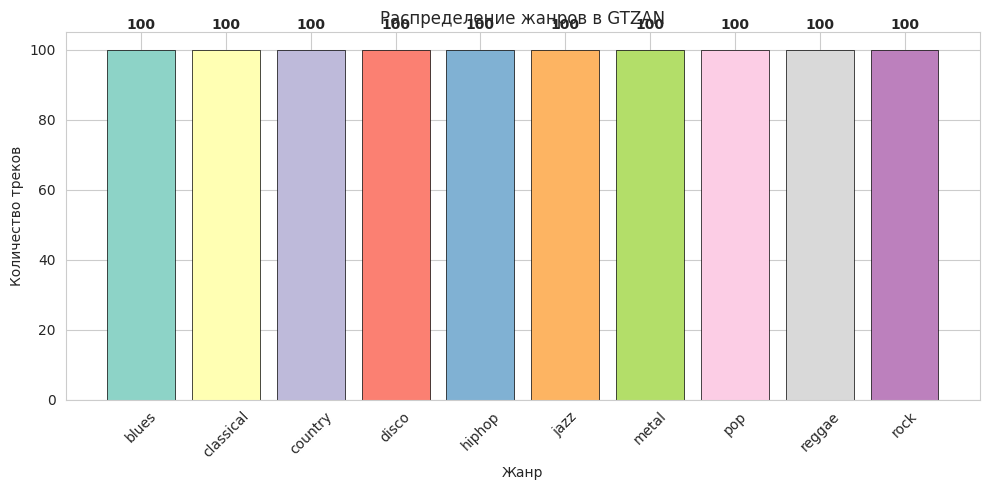

Датасет сбалансирован: по 100 треков на каждый из 10 жанров.


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
genre_counts = df['label'].value_counts()
colors = sns.color_palette('Set3', n_colors=len(genre_counts))
bars = ax.bar(genre_counts.index, genre_counts.values, color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, genre_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(val),
            ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Жанр')
ax.set_ylabel('Количество треков')
ax.set_title('Распределение жанров в GTZAN')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Датасет сбалансирован: по 100 треков на каждый из 10 жанров.')

## 2. Предобработка данных

Подготовим признаки: удалим нечисловые столбцы (`filename`, `label`), закодируем метки, масштабируем признаки и разделим на обучающую/тестовую выборки.

In [4]:
# Признаки и целевая переменная
X = df.drop(columns=['filename', 'label', 'length'])
y = df['label']

# Кодирование меток
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Классы:', le.classes_)
print(f'Признаков: {X.shape[1]}, Сэмплов: {X.shape[0]}')

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение: 80% train, 20% test (стратифицированное)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'\nОбучающая выборка: {X_train.shape[0]}, Тестовая: {X_test.shape[0]}')

Классы: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Признаков: 57, Сэмплов: 1000

Обучающая выборка: 800, Тестовая: 200


## 3. Бинарная классификация

Для наглядной демонстрации ROC-анализа сначала решим бинарную задачу: **«classical» vs остальные жанры**. Жанр «classical» выбран потому, что классическая музыка акустически наиболее отличается от других жанров.

In [5]:
# Бинарная задача: classical (1) vs rest (0)
classical_idx = list(le.classes_).index('classical')
y_binary = (y_encoded == classical_idx).astype(int)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
print(f'Класс 1 (classical): {y_binary.sum()} сэмплов')
print(f'Класс 0 (остальные): {(1 - y_binary).sum()} сэмплов')

Класс 1 (classical): 100 сэмплов
Класс 0 (остальные): 900 сэмплов


### 3.1 Линейная регрессия как классификатор

Линейная регрессия не предназначена для классификации, но может использоваться, если интерпретировать выход как «оценку принадлежности» и применить порог 0.5. Это наглядно демонстрирует, почему для классификации лучше использовать логистическую регрессию.

In [6]:
# Линейная регрессия (бинарная задача)
lr_model = LinearRegression()
lr_model.fit(X_train_b, y_train_b)

# Предсказания (непрерывные значения)
y_pred_lr_raw = lr_model.predict(X_test_b)
# Порог 0.5 для классификации
y_pred_lr = (y_pred_lr_raw >= 0.5).astype(int)

print('=== Линейная регрессия (бинарная) ===')
print(classification_report(y_test_b, y_pred_lr, target_names=['rest', 'classical']))

# Confusion matrix
cm_lr = confusion_matrix(y_test_b, y_pred_lr)
print('Confusion matrix:')
print(cm_lr)

=== Линейная регрессия (бинарная) ===
              precision    recall  f1-score   support

        rest       0.98      0.99      0.99       180
   classical       0.89      0.85      0.87        20

    accuracy                           0.97       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.97      0.97      0.97       200



Confusion matrix:
[[178   2]
 [  3  17]]


### 3.2 Логистическая регрессия (бинарная)

Логистическая регрессия — модель, специально разработанная для классификации. Она выдаёт вероятности, которые можно использовать для ROC-анализа.

In [7]:
# Логистическая регрессия (бинарная задача)
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_b, y_train_b)

y_pred_logreg = logreg_model.predict(X_test_b)
y_proba_logreg = logreg_model.predict_proba(X_test_b)[:, 1]

print('=== Логистическая регрессия (бинарная) ===')
print(classification_report(y_test_b, y_pred_logreg, target_names=['rest', 'classical']))

cm_logreg = confusion_matrix(y_test_b, y_pred_logreg)
print('Confusion matrix:')
print(cm_logreg)

=== Логистическая регрессия (бинарная) ===
              precision    recall  f1-score   support

        rest       0.98      0.99      0.98       180
   classical       0.89      0.80      0.84        20

    accuracy                           0.97       200
   macro avg       0.93      0.89      0.91       200
weighted avg       0.97      0.97      0.97       200

Confusion matrix:
[[178   2]
 [  4  16]]


### 3.3 Confusion matrix — сравнение моделей

Confusion matrix визуализирует количество верных и ошибочных предсказаний для каждого класса.

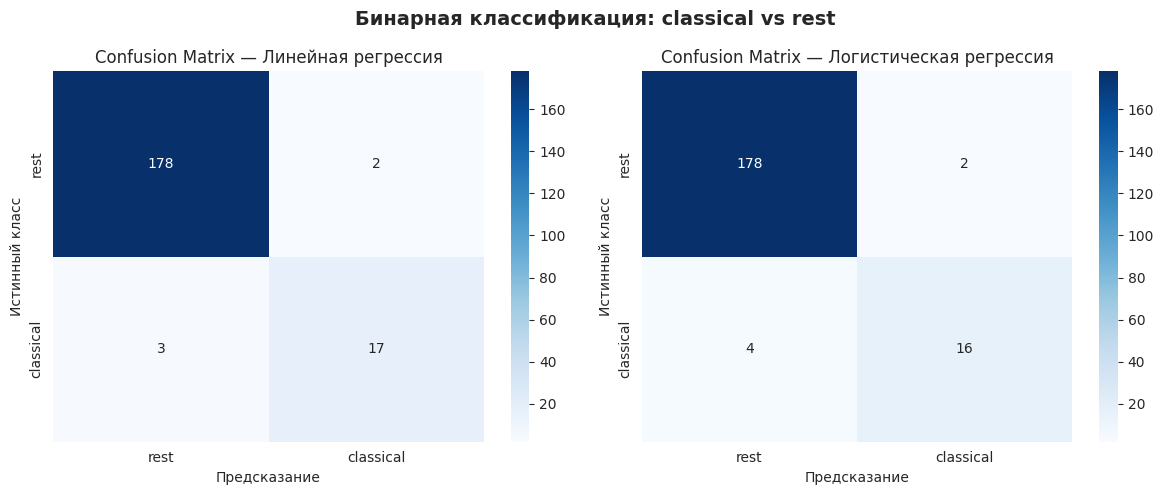

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(
    axes,
    [cm_lr, cm_logreg],
    ['Линейная регрессия', 'Логистическая регрессия']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['rest', 'classical'],
                yticklabels=['rest', 'classical'])
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Истинный класс')
    ax.set_title(f'Confusion Matrix — {title}')

plt.suptitle('Бинарная классификация: classical vs rest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 ROC-кривые — сравнение моделей

ROC-кривая показывает компромисс между полнотой (TPR) и долей ложных срабатываний (FPR). Чем ближе кривая к верхнему левому углу, тем лучше модель.

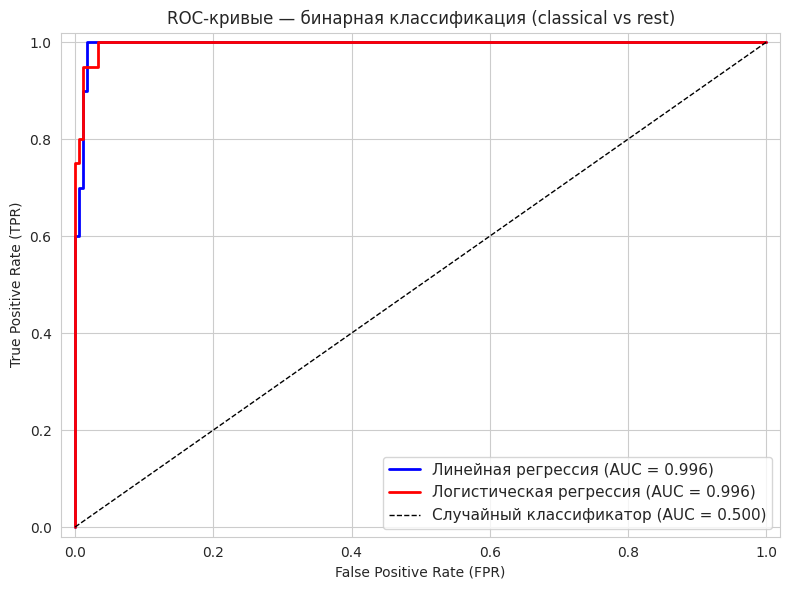

AUC линейной регрессии:      0.9956
AUC логистической регрессии:  0.9964


In [9]:
# ROC для линейной регрессии (используем raw predictions как scores)
# Обрезаем до [0, 1] для корректности
y_scores_lr = np.clip(y_pred_lr_raw, 0, 1)
fpr_lr, tpr_lr, _ = roc_curve(y_test_b, y_scores_lr)
auc_lr = roc_auc_score(y_test_b, y_scores_lr)

# ROC для логистической регрессии
fpr_logreg, tpr_logreg, _ = roc_curve(y_test_b, y_proba_logreg)
auc_logreg = roc_auc_score(y_test_b, y_proba_logreg)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr, tpr_lr, 'b-', linewidth=2,
        label=f'Линейная регрессия (AUC = {auc_lr:.3f})')
ax.plot(fpr_logreg, tpr_logreg, 'r-', linewidth=2,
        label=f'Логистическая регрессия (AUC = {auc_logreg:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор (AUC = 0.500)')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC-кривые — бинарная классификация (classical vs rest)')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

print(f'AUC линейной регрессии:      {auc_lr:.4f}')
print(f'AUC логистической регрессии:  {auc_logreg:.4f}')

## 4. Мультиклассовая классификация (10 жанров)

Перейдём к полной задаче — классификации всех 10 жанров GTZAN. Логистическая регрессия со стратегией **One-vs-Rest** обучает 10 бинарных классификаторов, каждый отделяет один жанр от остальных.

In [10]:
# Мультиклассовая логистическая регрессия
logreg_multi = LogisticRegression(max_iter=2000, random_state=42)
logreg_multi.fit(X_train, y_train)

y_pred_multi = logreg_multi.predict(X_test)
y_proba_multi = logreg_multi.predict_proba(X_test)

print('=== Логистическая регрессия (мультикласс, 10 жанров) ===')
print(classification_report(y_test, y_pred_multi, target_names=le.classes_))

=== Логистическая регрессия (мультикласс, 10 жанров) ===
              precision    recall  f1-score   support

       blues       0.68      0.65      0.67        20
   classical       0.95      0.95      0.95        20
     country       0.64      0.70      0.67        20
       disco       0.77      0.50      0.61        20
      hiphop       0.60      0.60      0.60        20
        jazz       0.71      0.85      0.77        20
       metal       0.94      0.80      0.86        20
         pop       0.84      0.80      0.82        20
      reggae       0.52      0.70      0.60        20
        rock       0.58      0.55      0.56        20

    accuracy                           0.71       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.71      0.71       200



### 4.1 Confusion matrix — мультиклассовая задача

Confusion matrix 10×10 показывает, какие жанры модель чаще путает между собой.

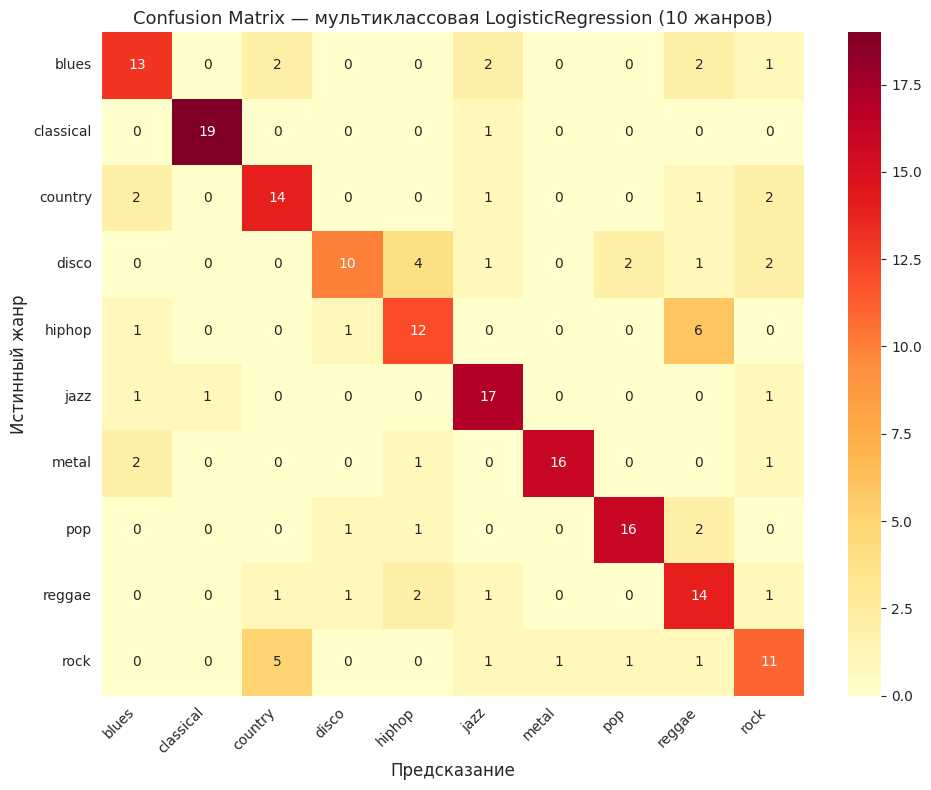

In [11]:
cm_multi = confusion_matrix(y_test, y_pred_multi)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel('Предсказание', fontsize=12)
ax.set_ylabel('Истинный жанр', fontsize=12)
ax.set_title('Confusion Matrix — мультиклассовая LogisticRegression (10 жанров)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2 OvR ROC-кривые по классам

Для мультиклассовой задачи строим ROC-кривую отдельно для каждого жанра (One-vs-Rest), а также вычисляем **micro-average** и **macro-average** AUC.

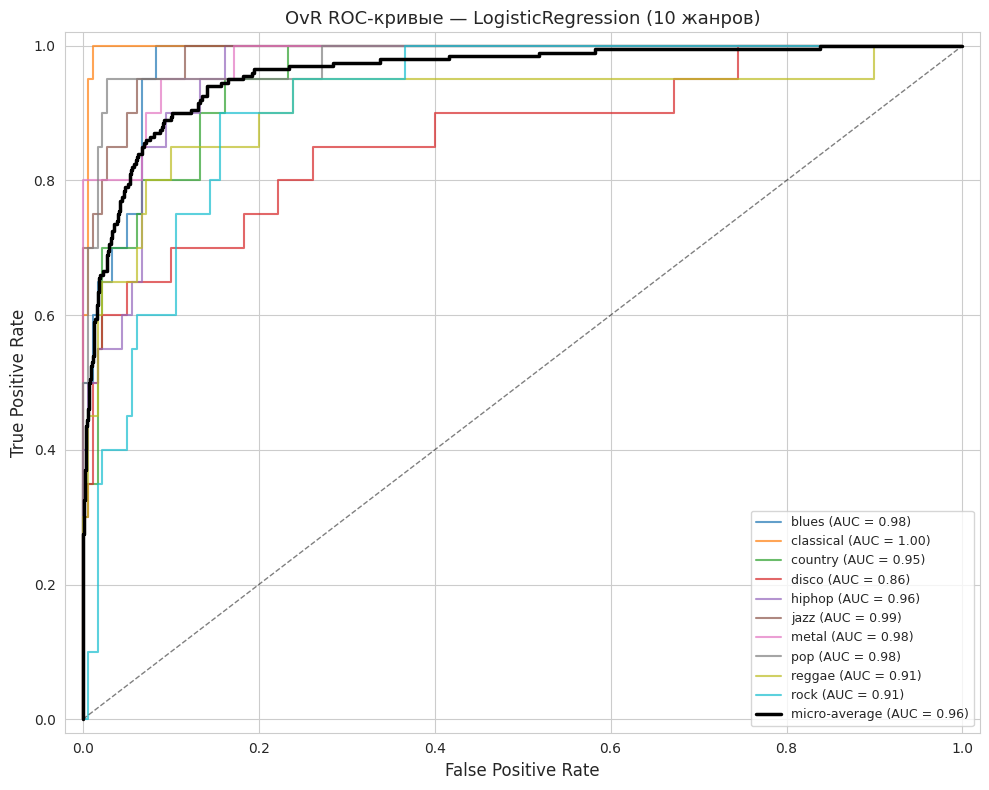

Micro-average AUC: 0.9587
Macro-average AUC: 0.9527


In [12]:
# Бинаризация меток для OvR ROC
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# ROC-кривая для каждого класса
fpr_dict, tpr_dict, auc_dict = {}, {}, {}
for i in range(n_classes):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_proba_multi[:, i])
    auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

# Micro-average ROC
fpr_dict['micro'], tpr_dict['micro'], _ = roc_curve(
    y_test_bin.ravel(), y_proba_multi.ravel()
)
auc_dict['micro'] = auc(fpr_dict['micro'], tpr_dict['micro'])

# Macro-average AUC
auc_dict['macro'] = np.mean([auc_dict[i] for i in range(n_classes)])

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    ax.plot(fpr_dict[i], tpr_dict[i], color=color, linewidth=1.5, alpha=0.7,
            label=f'{le.classes_[i]} (AUC = {auc_dict[i]:.2f})')

ax.plot(fpr_dict['micro'], tpr_dict['micro'], 'k-', linewidth=2.5,
        label=f'micro-average (AUC = {auc_dict["micro"]:.2f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('OvR ROC-кривые — LogisticRegression (10 жанров)', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

print(f'Micro-average AUC: {auc_dict["micro"]:.4f}')
print(f'Macro-average AUC: {auc_dict["macro"]:.4f}')

## 5. Кросс-валидация

Оценим стабильность моделей с помощью **стратифицированной 5-fold кросс-валидации**. Сравним линейную регрессию (с порогом 0.5) и логистическую регрессию на мультиклассовой задаче.

In [13]:
# Кросс-валидация для логистической регрессии
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg_cv = LogisticRegression(max_iter=2000, random_state=42)
scores_acc = cross_val_score(logreg_cv, X_scaled, y_encoded, cv=cv, scoring='accuracy')
scores_f1 = cross_val_score(logreg_cv, X_scaled, y_encoded, cv=cv, scoring='f1_macro')

# Кросс-валидация для линейной регрессии (ручная, т.к. не классификатор)
lr_acc_scores = []
for train_idx, test_idx in cv.split(X_scaled, y_encoded):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y_encoded[train_idx], y_encoded[test_idx]
    lr = LinearRegression()
    lr.fit(X_tr, y_tr)
    y_pred_raw = lr.predict(X_te)
    y_pred_cls = np.clip(np.round(y_pred_raw), 0, n_classes - 1).astype(int)
    lr_acc_scores.append(np.mean(y_pred_cls == y_te))

lr_acc_scores = np.array(lr_acc_scores)

print('=== Кросс-валидация (5-fold) ===')
print(f'\nЛогистическая регрессия:')
print(f'  Accuracy: {scores_acc.mean():.4f} ± {scores_acc.std():.4f}')
print(f'  F1-macro: {scores_f1.mean():.4f} ± {scores_f1.std():.4f}')
print(f'\nЛинейная регрессия (округление + clip):')
print(f'  Accuracy: {lr_acc_scores.mean():.4f} ± {lr_acc_scores.std():.4f}')

=== Кросс-валидация (5-fold) ===

Логистическая регрессия:
  Accuracy: 0.7070 ± 0.0163
  F1-macro: 0.7043 ± 0.0148

Линейная регрессия (округление + clip):
  Accuracy: 0.1430 ± 0.0136


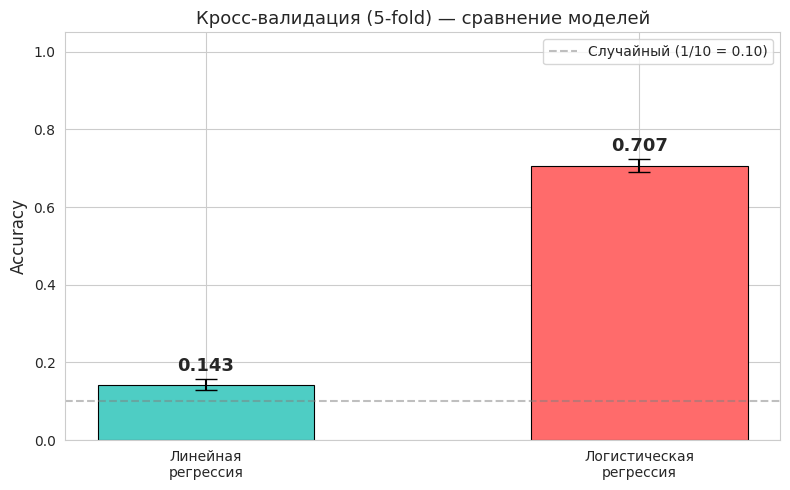

In [14]:
# Визуализация кросс-валидации
fig, ax = plt.subplots(figsize=(8, 5))

models = ['Линейная\nрегрессия', 'Логистическая\nрегрессия']
means = [lr_acc_scores.mean(), scores_acc.mean()]
stds = [lr_acc_scores.std(), scores_acc.std()]
colors_bar = ['#4ECDC4', '#FF6B6B']

bars = ax.bar(models, means, yerr=stds, capsize=8, color=colors_bar,
              edgecolor='black', linewidth=0.8, width=0.5)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Кросс-валидация (5-fold) — сравнение моделей', fontsize=13)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='Случайный (1/10 = 0.10)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Анализ коэффициентов модели

Логистическая регрессия — интерпретируемая модель. Посмотрим, какие признаки имеют наибольшее абсолютное значение весов (наиболее влияют на предсказание).

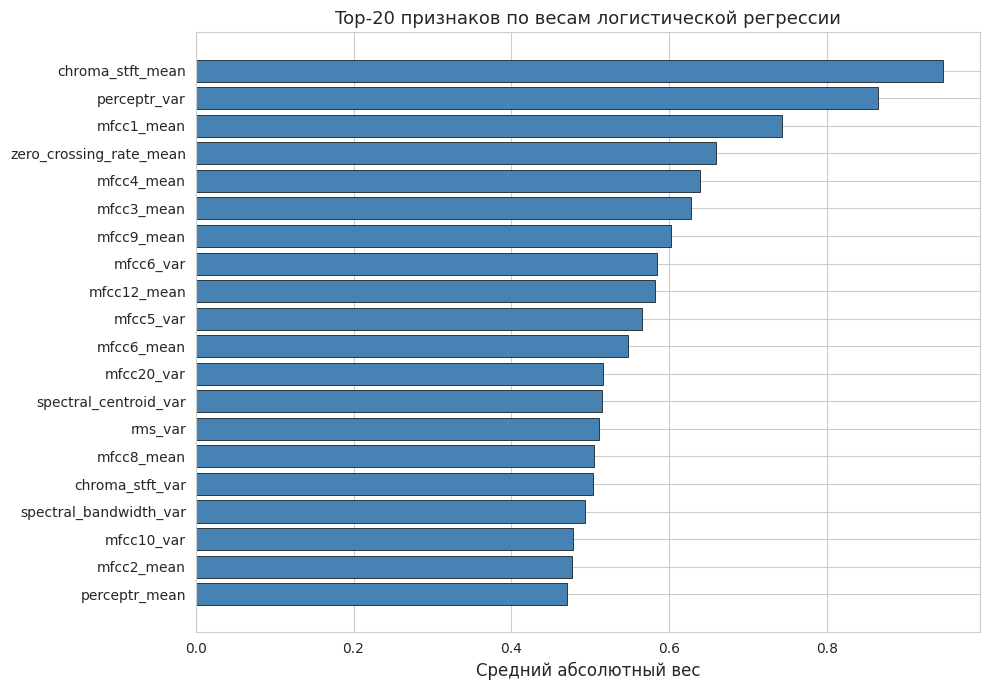

In [15]:
# Средние абсолютные веса по всем классам
feature_names = X.columns
coef_abs_mean = np.abs(logreg_multi.coef_).mean(axis=0)
coef_df = pd.DataFrame({'Признак': feature_names, 'Средний |вес|': coef_abs_mean})
coef_df = coef_df.sort_values('Средний |вес|', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(coef_df['Признак'], coef_df['Средний |вес|'], color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Средний абсолютный вес', fontsize=12)
ax.set_title('Top-20 признаков по весам логистической регрессии', fontsize=13)
plt.tight_layout()
plt.show()

## Выводы

1. **Линейная регрессия** может использоваться для классификации (с порогом), но это не оптимальный подход: предсказания выходят за пределы [0, 1], модель не оптимизирует метрики классификации.

2. **Логистическая регрессия** значительно лучше подходит для задачи классификации: она выдаёт калиброванные вероятности и оптимизирует log-loss.

3. **Бинарная классификация** (classical vs rest): обе модели показали высокий AUC, но логистическая регрессия стабильнее.

4. **Мультиклассовая задача** (10 жанров): логистическая регрессия с OvR стратегией справляется неплохо, при этом жанры с уникальными акустическими характеристиками (classical, metal) распознаются лучше, а близкие жанры (rock/country, disco/pop) чаще путаются.

5. **ROC-анализ** показал, что AUC для большинства жанров > 0.9, что говорит о хорошей разделимости данных GTZAN линейной моделью.

6. **Кросс-валидация** подтвердила стабильность результатов и превосходство логистической регрессии над линейной.

7. Наиболее информативные признаки для классификации жанров — MFCC-коэффициенты и спектральные характеристики.